Loading DLS data from 6 file(s)...
  Processing run 466797 from i21-466797.nxs
  Processing run 466798 from i21-466798.nxs
  Processing run 466799 from i21-466799.nxs
  Processing run 466800 from i21-466800.nxs
  Processing run 466801 from i21-466801.nxs
  Processing run 466802 from i21-466802.nxs
Successfully loaded 6 run(s).
Successfully normalized 6 run(s).


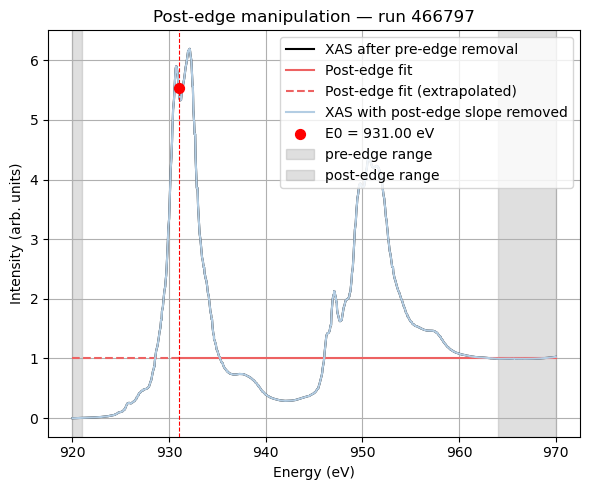

Dataset saved to C:\Users\leona\OneDrive - Universität Zürich UZH\LQMR group - PBCO_magnons\data\xas\csv_files\XAS_R_PVEVA01_LH_norm.csv
Dataset saved to C:\Users\leona\OneDrive - Universität Zürich UZH\LQMR group - PBCO_magnons\data\xas\hdf5_files\XAS_R_PVEVA01_LH_norm.h5


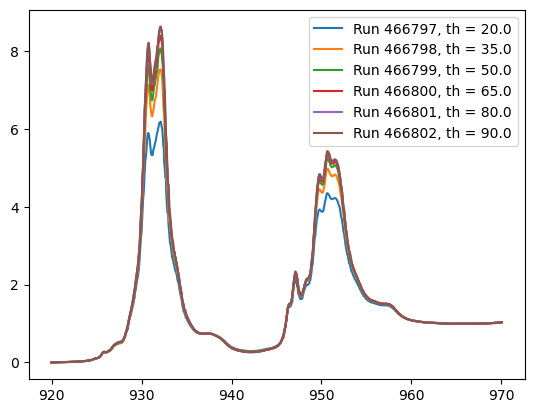

In [6]:
from raw_xas_data import DLS_XAS_Data
import matplotlib.pyplot as plt
import os
import numpy as np

#R_DCA325, LH, th dep
sample = "R_DCA325"
runs = [466791, 466792, 466793, 466794, 466795, 466796]
filename_out = "XAS_R_DCA325_LH_norm"

#PVEVA01, LH, th dep
sample = "PVEVA01"
runs = [466797, 466798, 466799, 466800, 466801, 466802]
filename_out = "XAS_R_PVEVA01_LH_norm"

#R_DCA325, LV, th_dep
# sample = "R_DCA325"
# runs = [466804, 466803]
# filename_out = "XAS_R_DCA325_LV_norm"

#PVEVA01, LV, th_dep
# sample = "PVEVA01"
# runs = [466805, 466806]
# filename_out = "XAS_R_PVEVA01_LV_norm"

range_pre_edge = [920, 921]
poly_order_pre_edge = 0
energy_edge = 931
range_post_edge = [964, 970]
poly_order_post_edge = 0

#R_DCA325, LH, th dep, O K edge
# sample = "R_DCA325"
# runs = [466823, 466824, 466825, 466826, 466827, 466828]
# filename_out = "XAS_R_DCA325_LH_norm_O_K_edge"

#PVEVA01, LH, th dep, O K edge
# sample = "PVEVA01"
# runs = [466830, 466831, 466832, 466833, 466834, 466835]
# filename_out = "XAS_R_PVEVA01_LH_norm_O_K_edge"

#R_DCA325, LV, th_dep
# sample = "R_DCA325"
# runs = [466822, 466821]
# filename_out = "XAS_R_DCA325_LV_norm_O_K_edge"

#PVEVA01, LV, th_dep
# sample = "PVEVA01"
# runs = [466829, 466836]
# filename_out = "XAS_R_PVEVA01_LV_norm_O_K_edge"


# range_pre_edge = [520, 525]
# energy_edge = 532
# range_post_edge = [550, 570]
# poly_order_pre_edge = 1
# poly_order_post_edge = 1


temp = 20
folder_out = r"C:\Users\leona\OneDrive - Universität Zürich UZH\LQMR group - PBCO_magnons\data\xas"
filepath = [rf"\\data.diamond.ac.uk\i21\data\2026\mm41868-2\i21-{ii}.nxs" for ii in runs]

additional_metadata = {
    "sample": sample,
    "T [K]": temp,
}

xas = DLS_XAS_Data(runs=runs, filepaths=filepath)
xas.load_data()
_ = xas.normalize_xas(normalization_method='i0 (arb. units)',
                  subtract_pre_edge=True,
                  pre_edge_params={"range_pre_edge": range_pre_edge, "poly_order_pre_edge": poly_order_pre_edge},
                  energy_edge=energy_edge,
                  remove_post_edge_slope=True,
                  post_edge_params={"range_post_edge": range_post_edge, "poly_order_post_edge": poly_order_post_edge},
                  normalize_by_mu_e0=True)
xas.plot_post_edge_manipulation()
# xas.save_dat_file(save_multiple_files=False,
#                   folder_out = os.path.join(folder_out, "dat_files"),
#                   filename_out=filename_out+".dat",
#                   additional_metadata=additional_metadata,
#                   )
# xas.save_json_file(save_multiple_files=False,
#                   folder_out = os.path.join(folder_out, "json_files"),
#                   filename_out=filename_out.replace('.dat', '.json'),
#                   additional_metadata=additional_metadata,
#     )

xas.save_csv_file(folder_out = os.path.join(folder_out, "csv_files"),
                    filename_out=filename_out+".csv",
                    variable_names = ['Energy (eV)', 'XAS_norm (arb. units)'],
                    units_names = ['eV', 'arb. units'],
                    additional_metadata=additional_metadata,
        )

xas.save_hdf5_file(folder_out = os.path.join(folder_out, "hdf5_files"),
                    filename_out=filename_out+".h5",
                    additional_metadata=additional_metadata,
                    metadata_to_save=['run','th','chi','phi','polarization'],
                    variable_names=['Energy (eV)', 'XAS_norm (arb. units)'],
                    )


plt.figure()
for ii, var_name in enumerate(xas.ds.data_vars):
    da = xas.ds[var_name]
    energy = da.sel(variable='Energy (eV)')
    mu_norm = da.sel(variable='XAS_norm (arb. units)')
    theta = da.attrs.get('th', None)
    theta_str = f"{np.round(theta)}" if theta is not None else "N/A"
    plt.plot(energy, mu_norm, label=f'Run {runs[ii]}, th = {theta_str}')
    plt.legend()

